In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import rcParams
from matplotlib import cm, colors
import scanpy as sc
import pandas as pd
import seaborn as sns
import scipy as sp
import numpy as np
import torch
from rich import print


# Define the path to the directory you want to change to
new_directory = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/H2M_sysVI/H2M_oligo/'

# Use os.chdir() to change the working directory
os.chdir(new_directory)

In [2]:
#### NEW COLORS FOR PLOTTING GENE EXPRESSION ON UMAPS

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import scanpy as sc

# Define a nice color map for gene expression
colors2 = plt.cm.PuRd(np.linspace(0, 1, 128))  # Use PuRd color map for deep red/purple color
colors3 = plt.cm.Greys_r(np.linspace(0.7, 0.8, 20))  # Greys for low values
colorsComb = np.vstack([colors3, colors2])
mymap = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [3]:
#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [4]:
plt.rcParams['figure.figsize']=(5,5) #rescale figures
sc.settings.verbosity = 3
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=300,transparent=True, fontsize=12) #color_map=mymap2)
sc.settings.figdir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/H2M_sysVI/H2M_oligo/figures/'
sc.logging.print_header()

scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.11.4 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.12


In [5]:
import pymn

In [6]:
plt.rcParams["axes.grid"] = False

In [7]:
#adata_mg.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_h2m_balanced_MG.h5ad')

# Add fine cell types original organism annotation

In [8]:
adata = sc.read('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_h2m_balanced_MG_3kHVG.h5ad')
adata

AnnData object with n_obs × n_vars = 90700 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    var: 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_eval_colors', 'cluster_annotation_colors', 'covariate_categ_orders', 'covariate_key_orders', 'layer_information', 'leiden', 'neighbors', 'publication_colors', 'sys_leiden_1_colors', 'system_order', 'type_fine_colors'

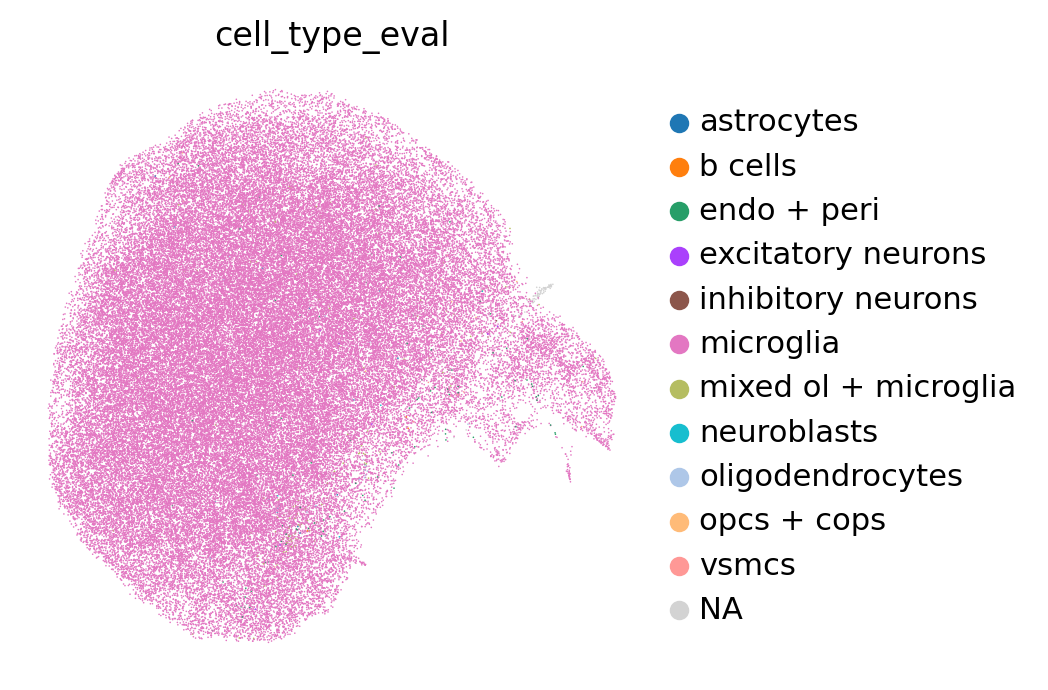

In [9]:
sc.pl.umap(adata,color='cell_type_eval', legend_fontweight= 'normal', frameon= False)

In [10]:
adata_ol = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/scVI_mdata_MG_working.h5ad')
adata_ol

AnnData object with n_obs × n_vars = 37619 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DCs

In [11]:
cluster_1_annotation = {
    'Microglia_A': 'Mg_A',
    'Microglia_B': 'Mg_B',
    'Microglia_C': 'Mg_C',
    'Microglia_D': 'Mg_D_DAM',
    'Microglia_E': 'Mg_E_DAM',
    'Microglia_F': 'Mg_F_DAM',
    'Microglia_G': 'Mg_G_DAM',
}

adata_ol.obs['MG_NEW_types_abbrev'] = adata_ol.obs['MG_NEW_types'].map(cluster_1_annotation).astype('category')

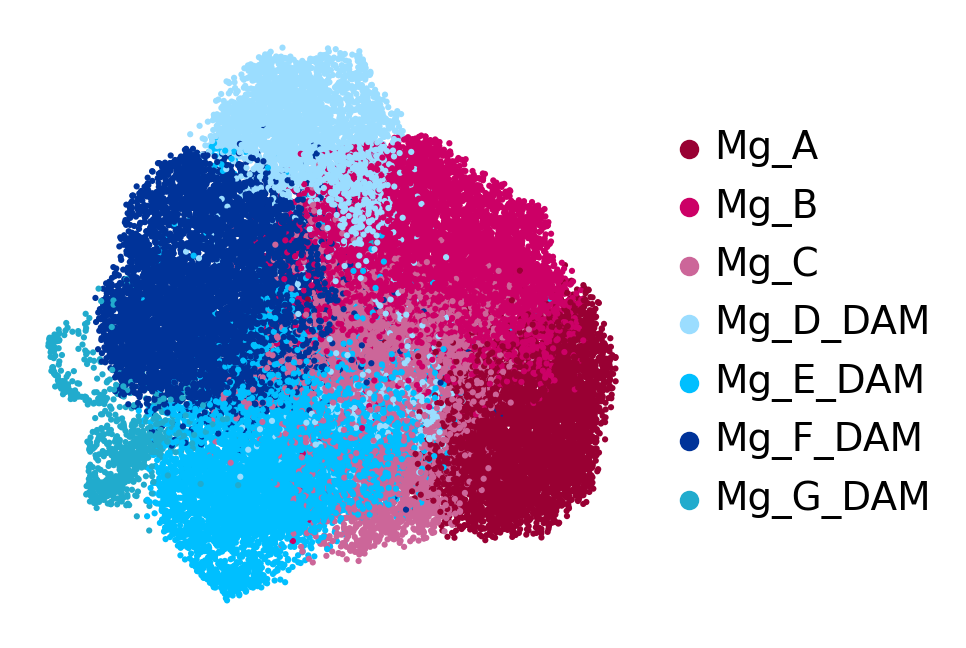

In [12]:
cluster_color_leiden = {
    'Mg_A': '#990033', 
    'Mg_E_DAM': '#00bfff', 
    'Mg_F_DAM': '#003399', 
    'Mg_D_DAM': '#9bddff', 
    'Mg_B': '#cc0066', 
    'Mg_C': '#cc6699',
    'Mg_G_DAM': '#21abcd',
}

# Define the desired order of cell types in the legend
desired_order = ['Mg_A', 'Mg_B', 'Mg_C', 'Mg_D_DAM', 'Mg_E_DAM', 
                 'Mg_F_DAM', 'Mg_G_DAM']

# Reorder the categories in the 'cell_type_fine_mm' column of adata_ol_ol
adata_ol.obs['MG_NEW_types_abbrev'] = pd.Categorical(adata_ol.obs['MG_NEW_types_abbrev'], 
                                                    categories=desired_order, 
                                                    ordered=True)

#Visualize the clustering and how this is reflected by different technical covariate
sc.pl.umap(adata_ol, color=['MG_NEW_types_abbrev'], legend_fontsize =float(14) , wspace=0.6, 
           cmap=mymap2,s=20,palette=cluster_color_leiden,
           legend_fontweight= 'bold', title='', frameon= False , 
           legend_fontoutline=1)

In [13]:
adata_mm = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/adata_mm_MG_fine_type_WORKING.h5ad')
adata_mm

AnnData object with n_obs × n_vars = 52981 × 19308
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'pct_counts_mt', 'pct_counts_ribo', 's_score', 'g2m_score', 'phase', 'type_fine', 'type_broad', 'cell_cycle_diff', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'system_map', 'indiv_treatment_time', 'lesion_status', 'lesion_condition', 'S_score', 'G2M_score', 'Cycling cells', 'S phase', 'Cycling_cells', 'S_phase_cells', 'cluster_annotation', 'cell_leiden_annotated', 'common_innate_immunity_signature', 'IRAS1', 'IRAS2', 'leiden_MG_r0.5', 'leiden_MG_r0.7', 'leiden_MG_r1', 'leiden_MG_r0.3', 'minimal_treatment_map', 'MG_type_fine', 'MG_leiden_annotated', 'NEW_treatment_map', 'individual_lesion_condition', 'MG_type_broad', 'MG_type_fine_reduced', 'MG_type_fine_NEW', 'MG_type_fine_NEW_NUMBERED', 'MG_type_fine_NUMBERED', 'MG_type_fine_LETTER', 'M

In [14]:
#cell_type = {str(i): '' for i in range(18)}
cell_type = {
    'cycl_Microglia': 'cycl_Microglia',  
    'Microglia_A': 'Microglia_A',    
    'Microglia_B': 'Microglia_B',
    'Microglia_C': 'Microglia_C',
    'Microglia_D': 'Microglia_D',  
    'Microglia_E': 'Microglia_E', 
    'Microglia_F': 'BAMs', 
}

adata_mm.obs['MG_type_fine_BAM'] = adata_mm.obs['MG_type_fine_NEW'].map(cell_type).astype('category')

In [15]:
#cell_type = {str(i): '' for i in range(18)}
cell_type = {
    'cycl_Microglia': 'cycling',  
    'Microglia_A': 'Mg_A',    
    'Microglia_B': 'Mg_B',
    'Microglia_C': 'Mg_C',
    'Microglia_D': 'Mg_D',  
    'Microglia_E': 'Mg_E', 
    'BAMs': 'BAMs', 
}

adata_mm.obs['MG_type_fine_NEW_REDUCED'] = adata_mm.obs['MG_type_fine_BAM'].map(cell_type).astype('category')

In [16]:
cluster2annotation = {
    'cycling': 'cycling',  
    'Mg_A': 'Mg_A',    
    'Mg_B': 'Mg_B',
    'Mg_C': 'Mg_C_DAM',
    'Mg_D': 'Mg_D_DAM',  
    'Mg_E': 'Mg_E_DAM', 
    'BAMs': 'BAMs', 
}

adata_mm.obs['MG_type_fine_DAM'] = adata_mm.obs['MG_type_fine_NEW_REDUCED'].map(cluster2annotation).astype('category')

In [17]:
# Define the desired order of cell types in the legend
desired_order = ['Mg_A', 'Mg_B', 'Mg_C_DAM', 'Mg_D_DAM', 'Mg_E_DAM', 'BAMs', 'cycling']

# Reorder the categories in the 'cell_type_fine_mm' column of adata_ol_ol
adata_mm.obs['MG_type_fine_DAM'] = pd.Categorical(adata_mm.obs['MG_type_fine_DAM'], 
                                                    categories=desired_order, 
                                                    ordered=True)

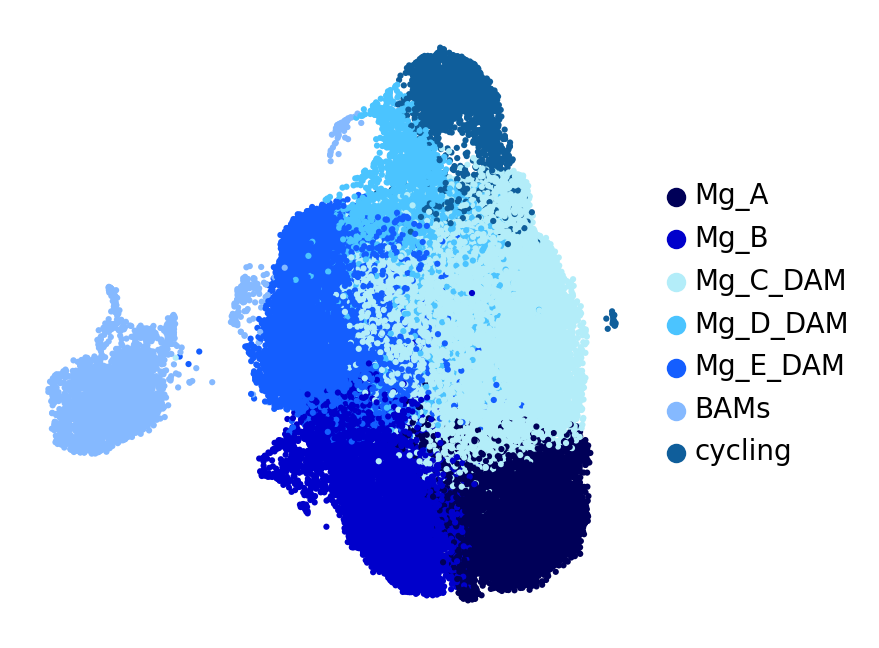

In [18]:
cluster_color = {     
    'cycling': '#0f5e9b',  
    'Mg_A': '#000058',    
    'Mg_B': '#0000cb',
    'Mg_C_DAM': '#b3edf9',
    'Mg_D_DAM': '#4bc4ff',  
    'Mg_E_DAM': '#145eff', 
    'BAMs': '#85b9ff', 
}

#Visualize the clustering and how this is reflected by different technical covariate
sc.pl.umap(adata_mm, color=['MG_type_fine_DAM'], legend_fontsize =float(10) , wspace=0.6, 
           cmap=mymap2,palette=cluster_color, title='',
           legend_fontweight= 'bold', frameon= False, s=20, 
           legend_fontoutline=1)

## Add column to adata (MG combined)

In [19]:
adata_ol.obs['MG_NEW_types_abbrev'].value_counts()

MG_NEW_types_abbrev
Mg_F_DAM    7840
Mg_B        7291
Mg_E_DAM    7067
Mg_A        5586
Mg_C        5132
Mg_D_DAM    3913
Mg_G_DAM     790
Name: count, dtype: int64

In [20]:
adata_mm.obs['MG_type_fine_DAM'].value_counts()

MG_type_fine_DAM
Mg_C_DAM    19698
Mg_E_DAM    11070
Mg_B         6772
Mg_A         6673
Mg_D_DAM     3795
BAMs         2842
cycling      2131
Name: count, dtype: int64

In [21]:
names_adata_ol = adata_ol.obs['MG_NEW_types_abbrev']
names_adata_mm = adata_mm.obs['MG_type_fine_DAM']

print(names_adata_ol[:5])

Ind98-Sample2:AAACCCATCCTGGTCT-1    Mg_B
Ind98-Sample2:AAAGGATCACTACCGG-1    Mg_A
Ind98-Sample2:AAAGTCCAGGGAGGGT-1    Mg_A
Ind98-Sample2:AAAGTGATCGGCTTCT-1    Mg_A
Ind98-Sample2:AAGAACAGTTATGTCG-1    Mg_A
Name: MG_NEW_types_abbrev, dtype: category
Categories (7, object): ['Mg_A' < 'Mg_B' < 'Mg_C' < 'Mg_D_DAM' < 'Mg_E_DAM' < 'Mg_F_DAM' < 'Mg_G_DAM']

In [22]:
dict_names_adata_ol = names_adata_ol.to_dict()
dict_names_adata_mm = names_adata_mm.to_dict()

print(dict(list(dict_names_adata_ol.items())[:10]))

{
    'Ind98-Sample2:AAACCCATCCTGGTCT-1': 'Mg_B',
    'Ind98-Sample2:AAAGGATCACTACCGG-1': 'Mg_A',
    'Ind98-Sample2:AAAGTCCAGGGAGGGT-1': 'Mg_A',
    'Ind98-Sample2:AAAGTGATCGGCTTCT-1': 'Mg_A',
    'Ind98-Sample2:AAGAACAGTTATGTCG-1': 'Mg_A',
    'Ind98-Sample2:AAGACAAGTTTGCAGT-1': 'Mg_B',
    'Ind98-Sample2:AAGGTAACACAACGTT-1': 'Mg_A',
    'Ind98-Sample2:AATAGAGAGGCTGTAG-1': 'Mg_C',
    'Ind98-Sample2:AATCGTGAGTTGGGAC-1': 'Mg_B',
    'Ind98-Sample2:ACAACCAGTGGCTTAT-1': 'Mg_B'
}

In [23]:
print(dict(list(dict_names_adata_mm.items())[:10]))

{
    'CTTCGGTTCGGTCGAC-1_adams': 'Mg_E_DAM',
    'CGATGCGAGATTAGAC-1_adams': 'cycling',
    'ACGTCCTAGTTTGGCT-1_adams': 'Mg_C_DAM',
    'GCCTGTTTCTAGCATG-1_adams': 'Mg_E_DAM',
    'ACCGTTCCACTCACTC-1_adams': 'Mg_C_DAM',
    'ACATGCAAGTCTCCTC-1_adams': 'cycling',
    'CATTGCCCACCTCAGG-1_adams': 'Mg_C_DAM',
    'TATTCCAGTTACGCCG-1_adams': 'cycling',
    'TGCGGCACAGGTCAGA-1_adams': 'Mg_D_DAM',
    'TAGTGCATCCTTCGAC-1_adams': 'cycling'
}

In [24]:
dict_names_adata_ol = {key + "_human": value for key, value in dict_names_adata_ol.items()}
print(dict(list(dict_names_adata_ol.items())[:5]))

{
    'Ind98-Sample2:AAACCCATCCTGGTCT-1_human': 'Mg_B',
    'Ind98-Sample2:AAAGGATCACTACCGG-1_human': 'Mg_A',
    'Ind98-Sample2:AAAGTCCAGGGAGGGT-1_human': 'Mg_A',
    'Ind98-Sample2:AAAGTGATCGGCTTCT-1_human': 'Mg_A',
    'Ind98-Sample2:AAGAACAGTTATGTCG-1_human': 'Mg_A'
}

In [25]:
dict_names_adata_mm = {key + "_mouse": value for key, value in dict_names_adata_mm.items()}
print(dict(list(dict_names_adata_mm.items())[:5]))

{
    'CTTCGGTTCGGTCGAC-1_adams_mouse': 'Mg_E_DAM',
    'CGATGCGAGATTAGAC-1_adams_mouse': 'cycling',
    'ACGTCCTAGTTTGGCT-1_adams_mouse': 'Mg_C_DAM',
    'GCCTGTTTCTAGCATG-1_adams_mouse': 'Mg_E_DAM',
    'ACCGTTCCACTCACTC-1_adams_mouse': 'Mg_C_DAM'
}

In [26]:
# First, ensure indices match
adata_all_indices = adata.obs.index

# Create a dictionary to update 'refined_cluster_annotation'
update_dict = {}
update_dict.update({idx: dict_names_adata_ol[idx] for idx in dict_names_adata_ol if idx in adata_all_indices})
update_dict.update({idx: dict_names_adata_mm[idx] for idx in dict_names_adata_mm if idx in adata_all_indices})

In [27]:
adata.obs['refined_cluster_annotation'] = adata.obs['cell_type_eval']

In [28]:
# Replace 'refined_cluster_annotation' values based on the update dictionary
adata.obs['refined_cluster_annotation'] = adata.obs.index.map(update_dict)

# Optionally, you can fill missing values with original values from 'cluster_annotation'
adata.obs['refined_cluster_annotation'].fillna(adata.obs['cell_type_eval'], inplace=True)

/tmp/2306306.1.long/ipykernel_2651959/2032830489.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['refined_cluster_annotation'].fillna(adata.obs['cell_type_eval'], inplace=True)


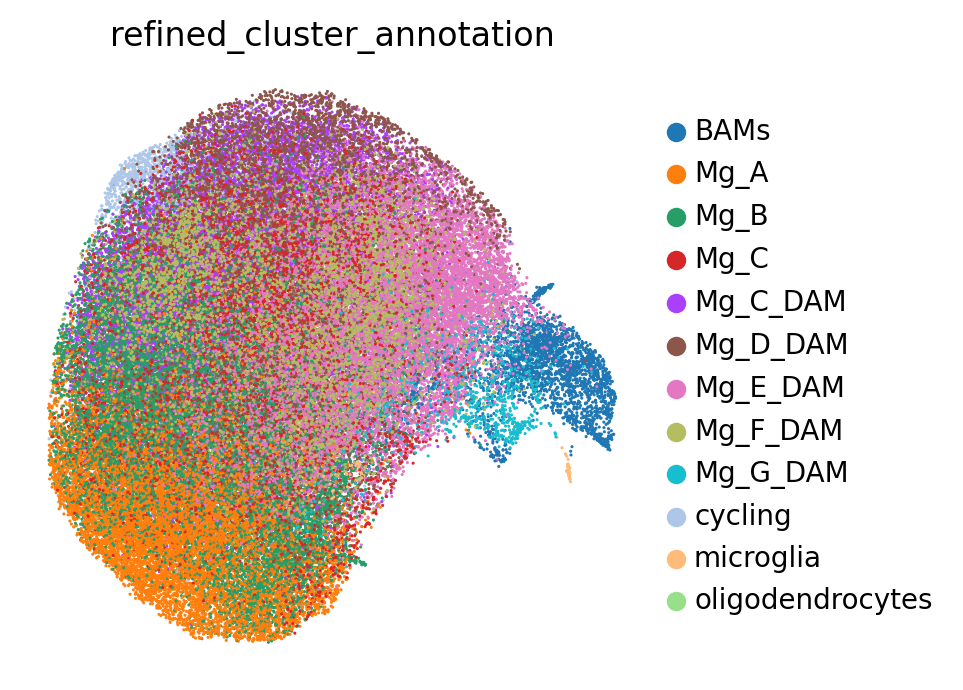

In [29]:
#Visualize the clustering and how this is reflected by different technical covariate
sc.pl.umap(adata, color=['refined_cluster_annotation'], legend_fontsize =float(10) , wspace=0.6, 
           cmap=mymap2, s=5,legend_fontweight= 'bold', frameon= False , legend_fontoutline=1)

In [30]:
adata.obs['refined_cluster_annotation'].value_counts()

refined_cluster_annotation
Mg_C_DAM            19698
Mg_E_DAM            18137
Mg_B                14063
Mg_A                12259
Mg_F_DAM             7840
Mg_D_DAM             7708
Mg_C                 5132
BAMs                 2842
cycling              2131
Mg_G_DAM              790
microglia              98
oligodendrocytes        2
Name: count, dtype: int64

In [31]:
adata.obs['organism'].value_counts()

organism
mouse    53015
human    37685
Name: count, dtype: int64

# RESET .X to get back all genes!!!

In [32]:
adata

AnnData object with n_obs × n_vars = 90700 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    var: 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_eval_colors', 'cluster_annotation_colors', 'covariate_categ_orders', 'covariate_key_orders', 'layer_information', 'leiden', 'neighbors', 'publication_colors', 'sys_leiden_1_colors', 'system_order', 'type_fine_colors'

In [33]:
# Check the dimensions of mdata.raw
print("Dimensions of adata.raw:", adata.raw.X.shape)

Dimensions of adata.raw:
(90700, 14311)

In [34]:
# Check the dimensions of mdata.X
print("Dimensions of adata.X:", adata.X.shape)

Dimensions of adata.X:
(90700, 1796)

In [35]:
adata_h2m_raw=adata.raw.to_adata()
adata_h2m_raw

AnnData object with n_obs × n_vars = 90700 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_eval_colors', 'cluster_annotation_colors', 'covariate_categ_orders', 'covariate_key_orders', 'layer_information', 'leiden', 'neighbors', 'publication_colors', 'sys_leiden_1_colors', 'system_order', 'type_fine_colors', 'umap', 'refined

In [36]:
adata_h2m=adata_h2m_raw.copy()
adata_h2m.layers['counts']=adata_h2m[adata_h2m.obs_names,adata_h2m.var_names].X.copy()

In [37]:
print(adata_h2m.X[:10, :10])

(0, 5)        1.0
  (0, 8)        1.0
  (0, 9)        3.0
  (1, 9)        2.0
  (2, 9)        4.0
  (3, 9)        3.0
  (4, 9)        1.0
  (5, 8)        1.0
  (5, 9)        5.0
  (6, 9)        2.0
  (7, 9)        1.0
  (8, 8)        1.0
  (8, 9)        5.0
  (9, 5)        1.0
  (9, 9)        1.0

In [38]:
adata_h2m_raw.raw = adata_h2m

In [39]:
sc.pp.normalize_total(adata_h2m, target_sum=1e4)
adata_h2m.layers["log1p_norm"] = sc.pp.log1p(adata_h2m.X)

normalizing counts per cell
    finished (0:00:00)


In [40]:
print(adata_h2m.X[:10, :10])

(0, 5)        0.7498557134556231
  (0, 8)        0.7498557134556231
  (0, 9)        1.4701950982701464
  (1, 9)        1.386594436140897
  (2, 9)        1.8633263913694773
  (3, 9)        1.6561467421820604
  (4, 9)        0.9193314832649789
  (5, 8)        0.9506154744152296
  (5, 9)        2.1901449017481576
  (6, 9)        1.4512643343557399
  (7, 9)        0.9565958433543011
  (8, 8)        0.9863838330413786
  (8, 9)        2.241517923292962
  (9, 5)        0.9861729931348484
  (9, 9)        0.9861729931348484

In [41]:
# Check dimensions of each layer
print("counts layer shape:", adata_h2m.layers['counts'].shape)
print("log1p_norm layer shape:", adata_h2m.layers['log1p_norm'].shape)

counts layer shape:
(90700, 14311)

log1p_norm layer shape:
(90700, 14311)

In [42]:
adata_h2m

AnnData object with n_obs × n_vars = 90700 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_eval_colors', 'cluster_annotation_colors', 'covariate_categ_orders', 'covariate_key_orders', 'layer_information', 'leiden', 'neighbors', 'publication_colors', 'sys_leiden_1_colors', 'system_order', 'type_fine_colors', 'umap', 'refined

## Orthos-- SKIP

In [ ]:
adata_hlog = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/mm_converted_OL.h5ad')
adata_hlog

In [ ]:
# Find intersection of gene names
shared_genes = adata_h2m.var_names.intersection(adata_hlog.var_names)

print(f"Number of shared genes: {len(shared_genes)}")

In [ ]:
adata_h2m_sub = adata_h2m[:, adata_hlog.var_names].copy()

In [ ]:
adata_h2m_sub

In [ ]:
# Add all var columns from adata_hlog
for col in adata_hlog.var.columns:
    adata_h2m_sub.var[col] = adata_hlog.var[col].values
    
adata_h2m_sub.var

In [ ]:
# Check dimensions of each layer
print("counts layer shape:", adata_h2m_sub.layers['counts'].shape)
print("log1p_norm layer shape:", adata_h2m_sub.layers['log1p_norm'].shape)

In [ ]:
adata_h2m_sub.X = adata_h2m_sub.layers["log1p_norm"].copy()

In [ ]:
print(type(adata_h2m_sub.X))
print(adata_h2m_sub.X.shape)

In [ ]:
import scipy
adata_h2m_sub.X = scipy.sparse.csr_matrix(adata_h2m_sub.X)
adata_h2m_sub.X

In [ ]:
print(adata_h2m_sub.X[:10, :10].toarray())

In [ ]:
print((adata_h2m_sub.X != 0).sum())  # number of non-zero entries

In [ ]:
# Check the dimensions of mdata.X
print("Dimensions of adata.X:", adata_h2m_sub.X.shape)

In [ ]:
print(adata_h2m_sub.X[:10, :10])

# Add pyMN analysis

In [43]:
num_batches = adata_h2m.obs['batch'].nunique()
print(f"Total number of unique batches: {num_batches}")

Total number of unique batches: 122

In [44]:
# Count number of cells per batch
batch_sizes = adata_h2m.obs['batch'].value_counts()
print(batch_sizes)

# Optional: specifically look at tiny batches
small_batches = batch_sizes[batch_sizes <= 1]
print("Batches with 0 or 1 cells:")
print(small_batches)

batch
26    6379
18    5961
23    5935
19    4449
25    3361
      ... 
17      13
8       13
35      12
39       6
71       1
Name: count, Length: 122, dtype: int64

Batches with 0 or 1 cells:

batch
71    1
Name: count, dtype: int64

In [45]:
adata_h2m.obs['refined_cluster_annotation'].value_counts()

refined_cluster_annotation
Mg_C_DAM            19698
Mg_E_DAM            18137
Mg_B                14063
Mg_A                12259
Mg_F_DAM             7840
Mg_D_DAM             7708
Mg_C                 5132
BAMs                 2842
cycling              2131
Mg_G_DAM              790
microglia              98
oligodendrocytes        2
Name: count, dtype: int64

In [46]:
adata_sub = adata_h2m[adata_h2m.obs['batch'] != '71'].copy()

In [47]:
adata_sub = adata_sub[
    ~adata_sub.obs['refined_cluster_annotation'].isin(['oligodendrocytes', 'microglia'])
].copy()

In [48]:
adata_sub

AnnData object with n_obs × n_vars = 90599 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_eval_colors', 'cluster_annotation_colors', 'covariate_categ_orders', 'covariate_key_orders', 'layer_information', 'leiden', 'neighbors', 'publication_colors', 'sys_leiden_1_colors', 'system_order', 'type_fine_colors', 'umap', 'refined

In [49]:
# Check dimensions of each layer
print("counts layer shape:", adata_sub.layers['counts'].shape)
print("log1p_norm layer shape:", adata_sub.layers['log1p_norm'].shape)

counts layer shape:
(90599, 14311)

log1p_norm layer shape:
(90599, 14311)

In [50]:
# HVGs on the final cell subset
sc.pp.highly_variable_genes(
     adata=adata_sub, n_top_genes=2000, batch_key='batch', subset=False)

extracting highly variable genes


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:383: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)


    finished (0:00:09)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [51]:
print(adata_sub.var["highly_variable"].sum())

2000

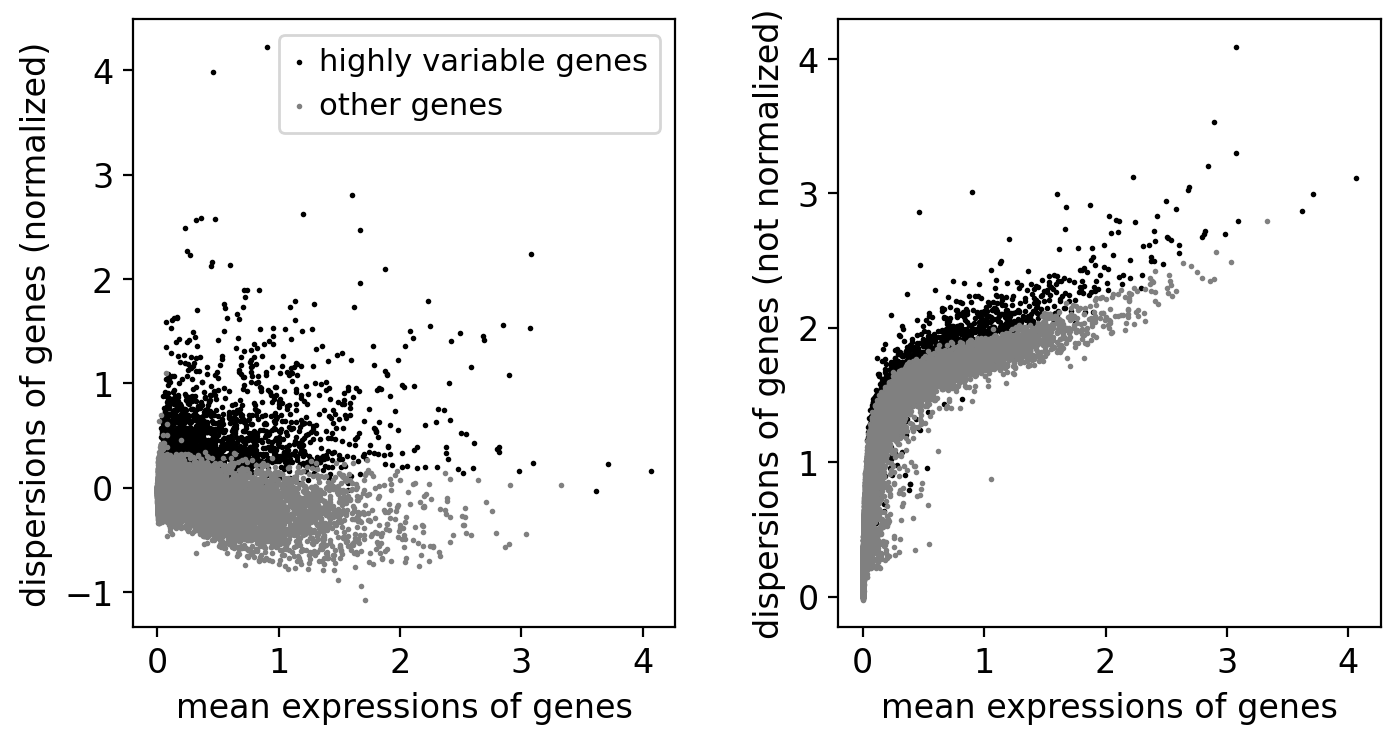

In [52]:
sc.pl.highly_variable_genes(adata_sub)

In [53]:
adata_sub.obs['organism_cluster'] = adata_sub.obs['organism'].astype(str) + "_" + adata_sub.obs['refined_cluster_annotation'].astype(str)

In [54]:
adata_sub.obs['cell.type'] = adata_sub.obs['organism_cluster'].astype(str)
adata_sub.obs['study_id'] = adata_sub.obs['organism'].astype(str)

In [55]:
adata_sub.obs['cell.type'].value_counts()

cell.type
mouse_Mg_C_DAM    19698
mouse_Mg_E_DAM    11070
human_Mg_F_DAM     7840
human_Mg_B         7291
human_Mg_E_DAM     7067
mouse_Mg_B         6772
mouse_Mg_A         6673
human_Mg_A         5585
human_Mg_C         5132
human_Mg_D_DAM     3913
mouse_Mg_D_DAM     3795
mouse_BAMs         2842
mouse_cycling      2131
human_Mg_G_DAM      790
Name: count, dtype: int64

In [56]:
# Example: dictionary mapping organism_cluster -> cell.type
mapping = {
    "mouse_Mg_C_DAM": "mouse_Mg_C_DAM",
    "mouse_Mg_E_DAM": "mouse_Mg_E_DAM",
    "human_Mg_F_DAM": "human_Mg_F_DAM",
    "human_Mg_B": "human_Mg_B_homeo",
    "human_Mg_E_DAM": "human_Mg_E_DAM",
    "mouse_Mg_B": "mouse_Mg_B_homeo",
    "mouse_Mg_A": "mouse_Mg_A_homeo",
    "human_Mg_A": "human_Mg_A_homeo",
    "human_Mg_C": "human_Mg_C_homeo",
    "human_Mg_D_DAM": "human_Mg_D_DAM",
    "mouse_Mg_D_DAM": "mouse_Mg_D_DAM",
    "mouse_BAMs": "mouse_PVMs",
    "mouse_cycling": "mouse_cycling",
    "human_Mg_G_DAM": "human_PVMs",
}

adata_sub.obs["cell.type"] = adata_sub.obs["organism_cluster"].map(mapping)
adata_sub.obs['cell.type'].value_counts()

cell.type
mouse_Mg_C_DAM      19698
mouse_Mg_E_DAM      11070
human_Mg_F_DAM       7840
human_Mg_B_homeo     7291
human_Mg_E_DAM       7067
mouse_Mg_B_homeo     6772
mouse_Mg_A_homeo     6673
human_Mg_A_homeo     5585
human_Mg_C_homeo     5132
human_Mg_D_DAM       3913
mouse_Mg_D_DAM       3795
mouse_PVMs           2842
mouse_cycling        2131
human_PVMs            790
Name: count, dtype: int64

In [57]:
pymn.MetaNeighborUS(adata_sub,
                    study_col='study_id',
                    ct_col='cell.type',
                    fast_version=True)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


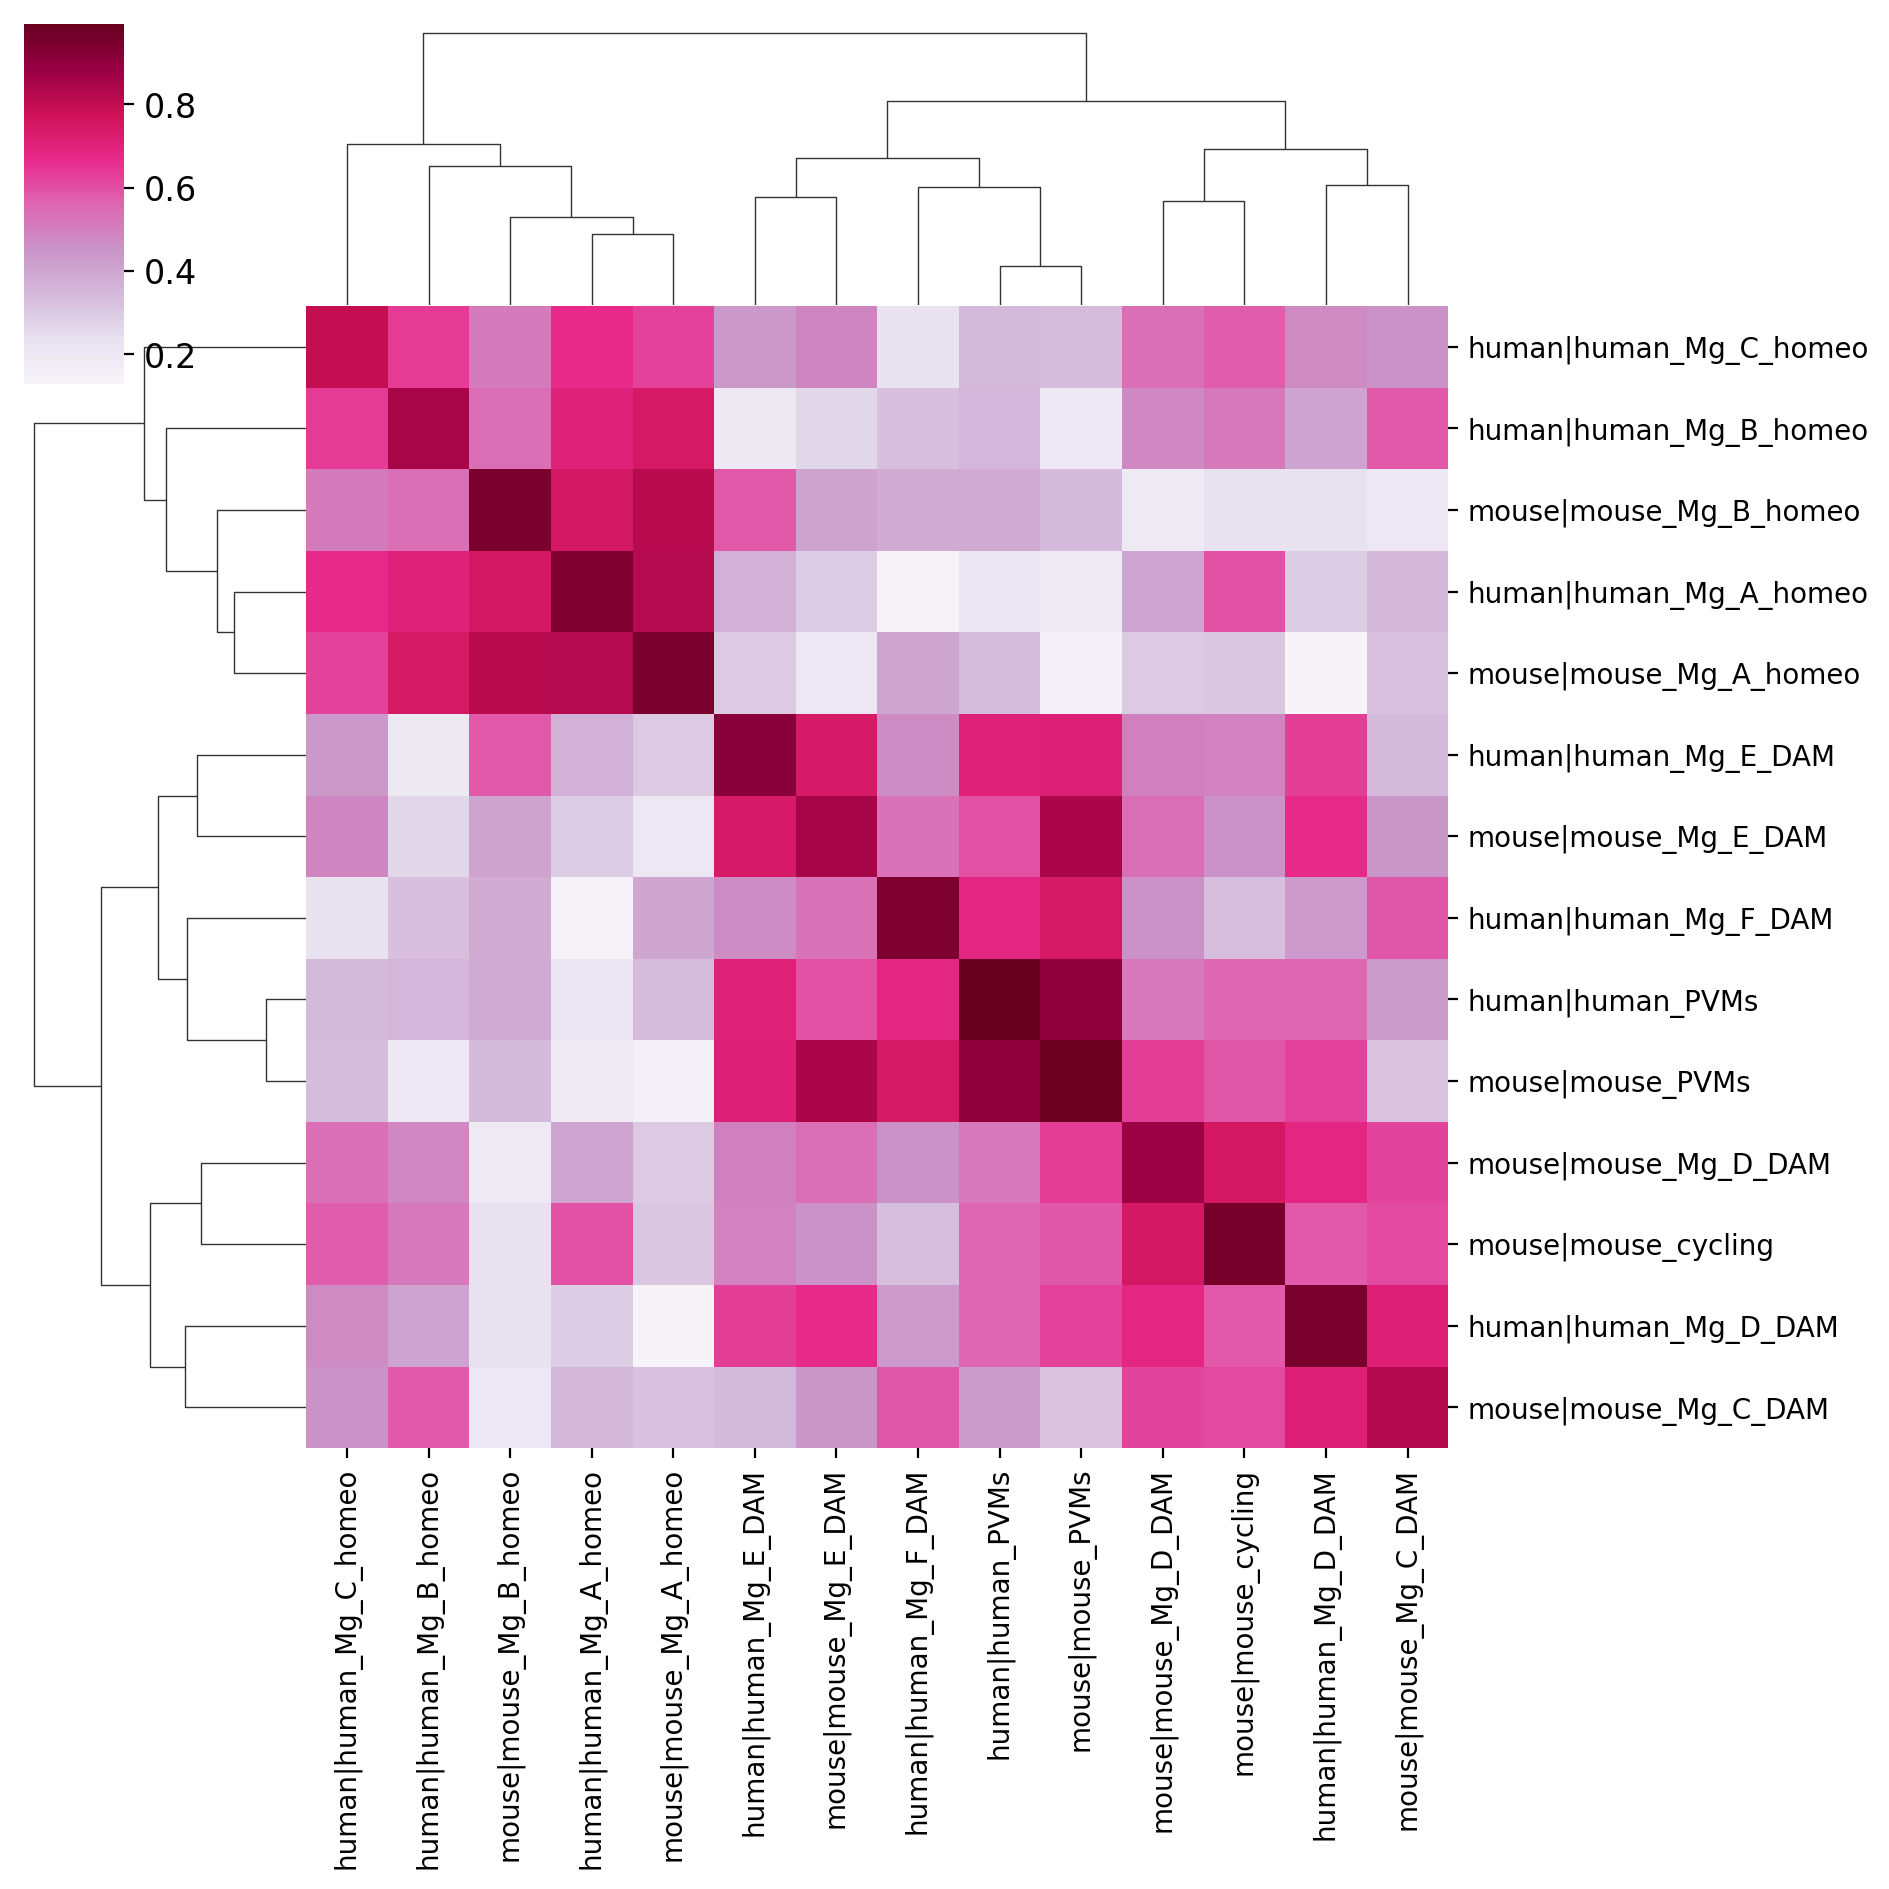

In [58]:
pymn.plotMetaNeighborUS(adata_sub, figsize=(10, 10), cmap='PuRd', fontsize=10)

In [59]:
adata_sub.obs['organism_cluster'].value_counts()

organism_cluster
mouse_Mg_C_DAM    19698
mouse_Mg_E_DAM    11070
human_Mg_F_DAM     7840
human_Mg_B         7291
human_Mg_E_DAM     7067
mouse_Mg_B         6772
mouse_Mg_A         6673
human_Mg_A         5585
human_Mg_C         5132
human_Mg_D_DAM     3913
mouse_Mg_D_DAM     3795
mouse_BAMs         2842
mouse_cycling      2131
human_Mg_G_DAM      790
Name: count, dtype: int64

In [60]:
pymn.MetaNeighborUS(adata_sub,
                    study_col='study_id',
                    ct_col='cell.type',
                    fast_version=True)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


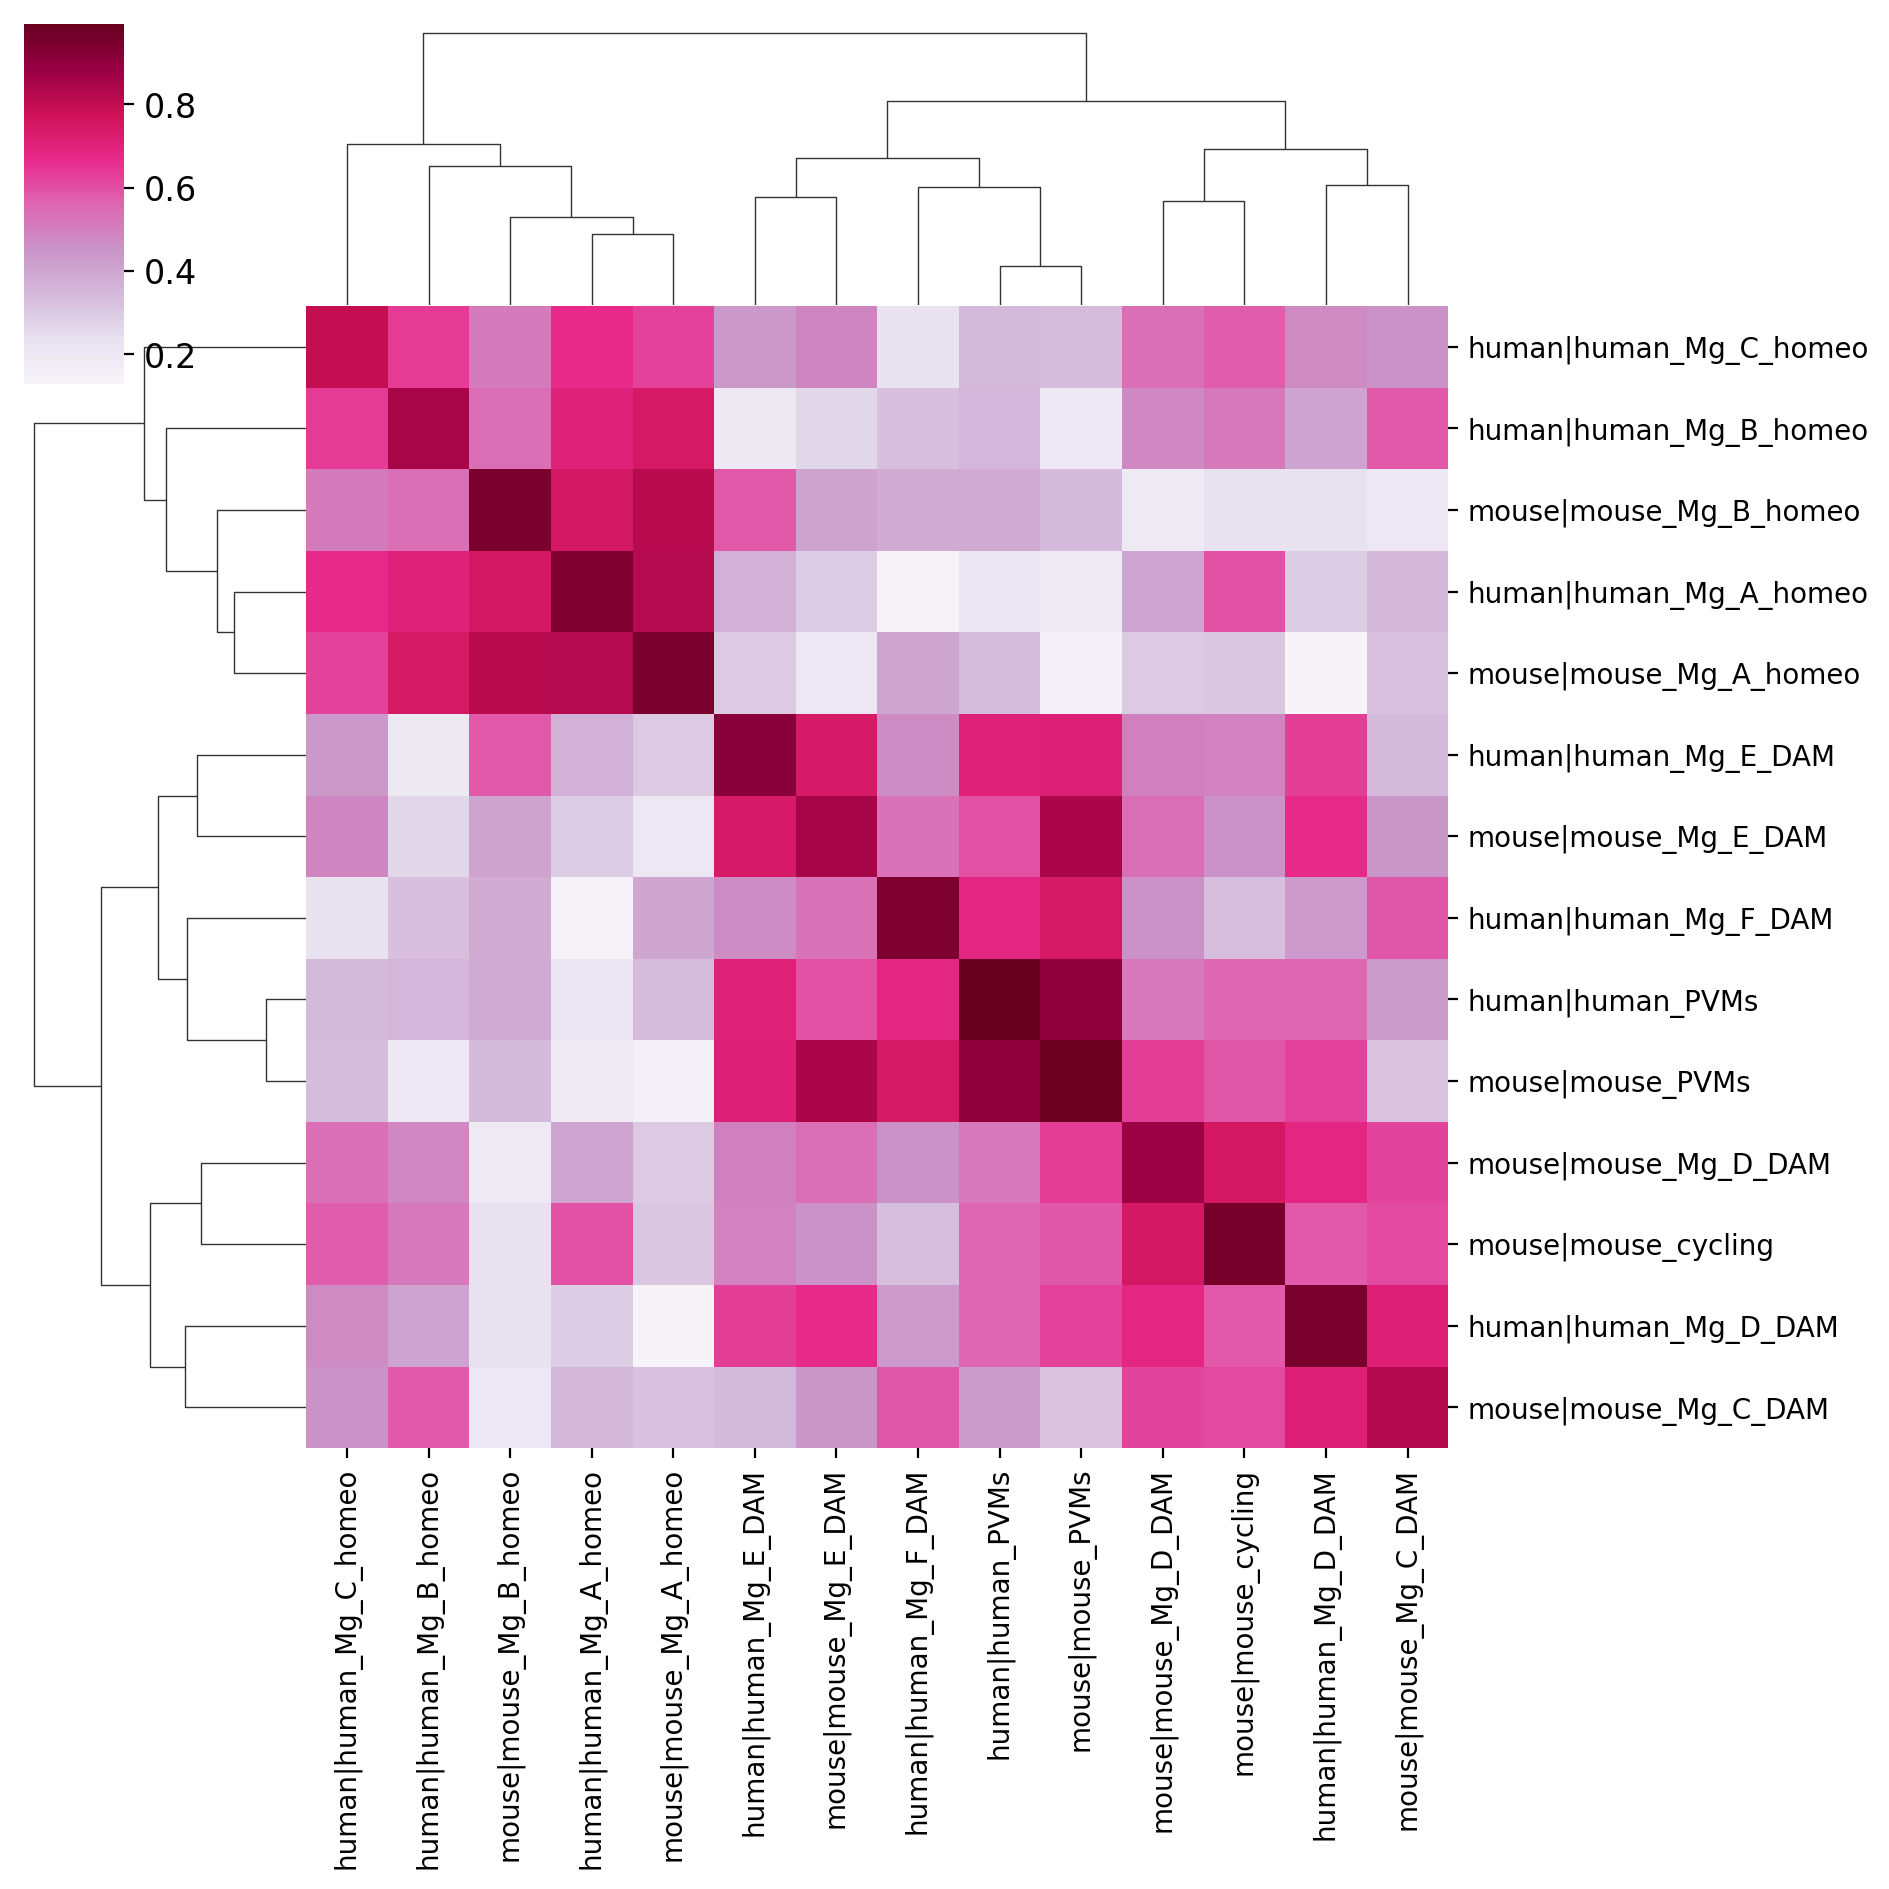

In [61]:
pymn.plotMetaNeighborUS(adata_sub, figsize=(10, 10), cmap='PuRd', fontsize=10)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


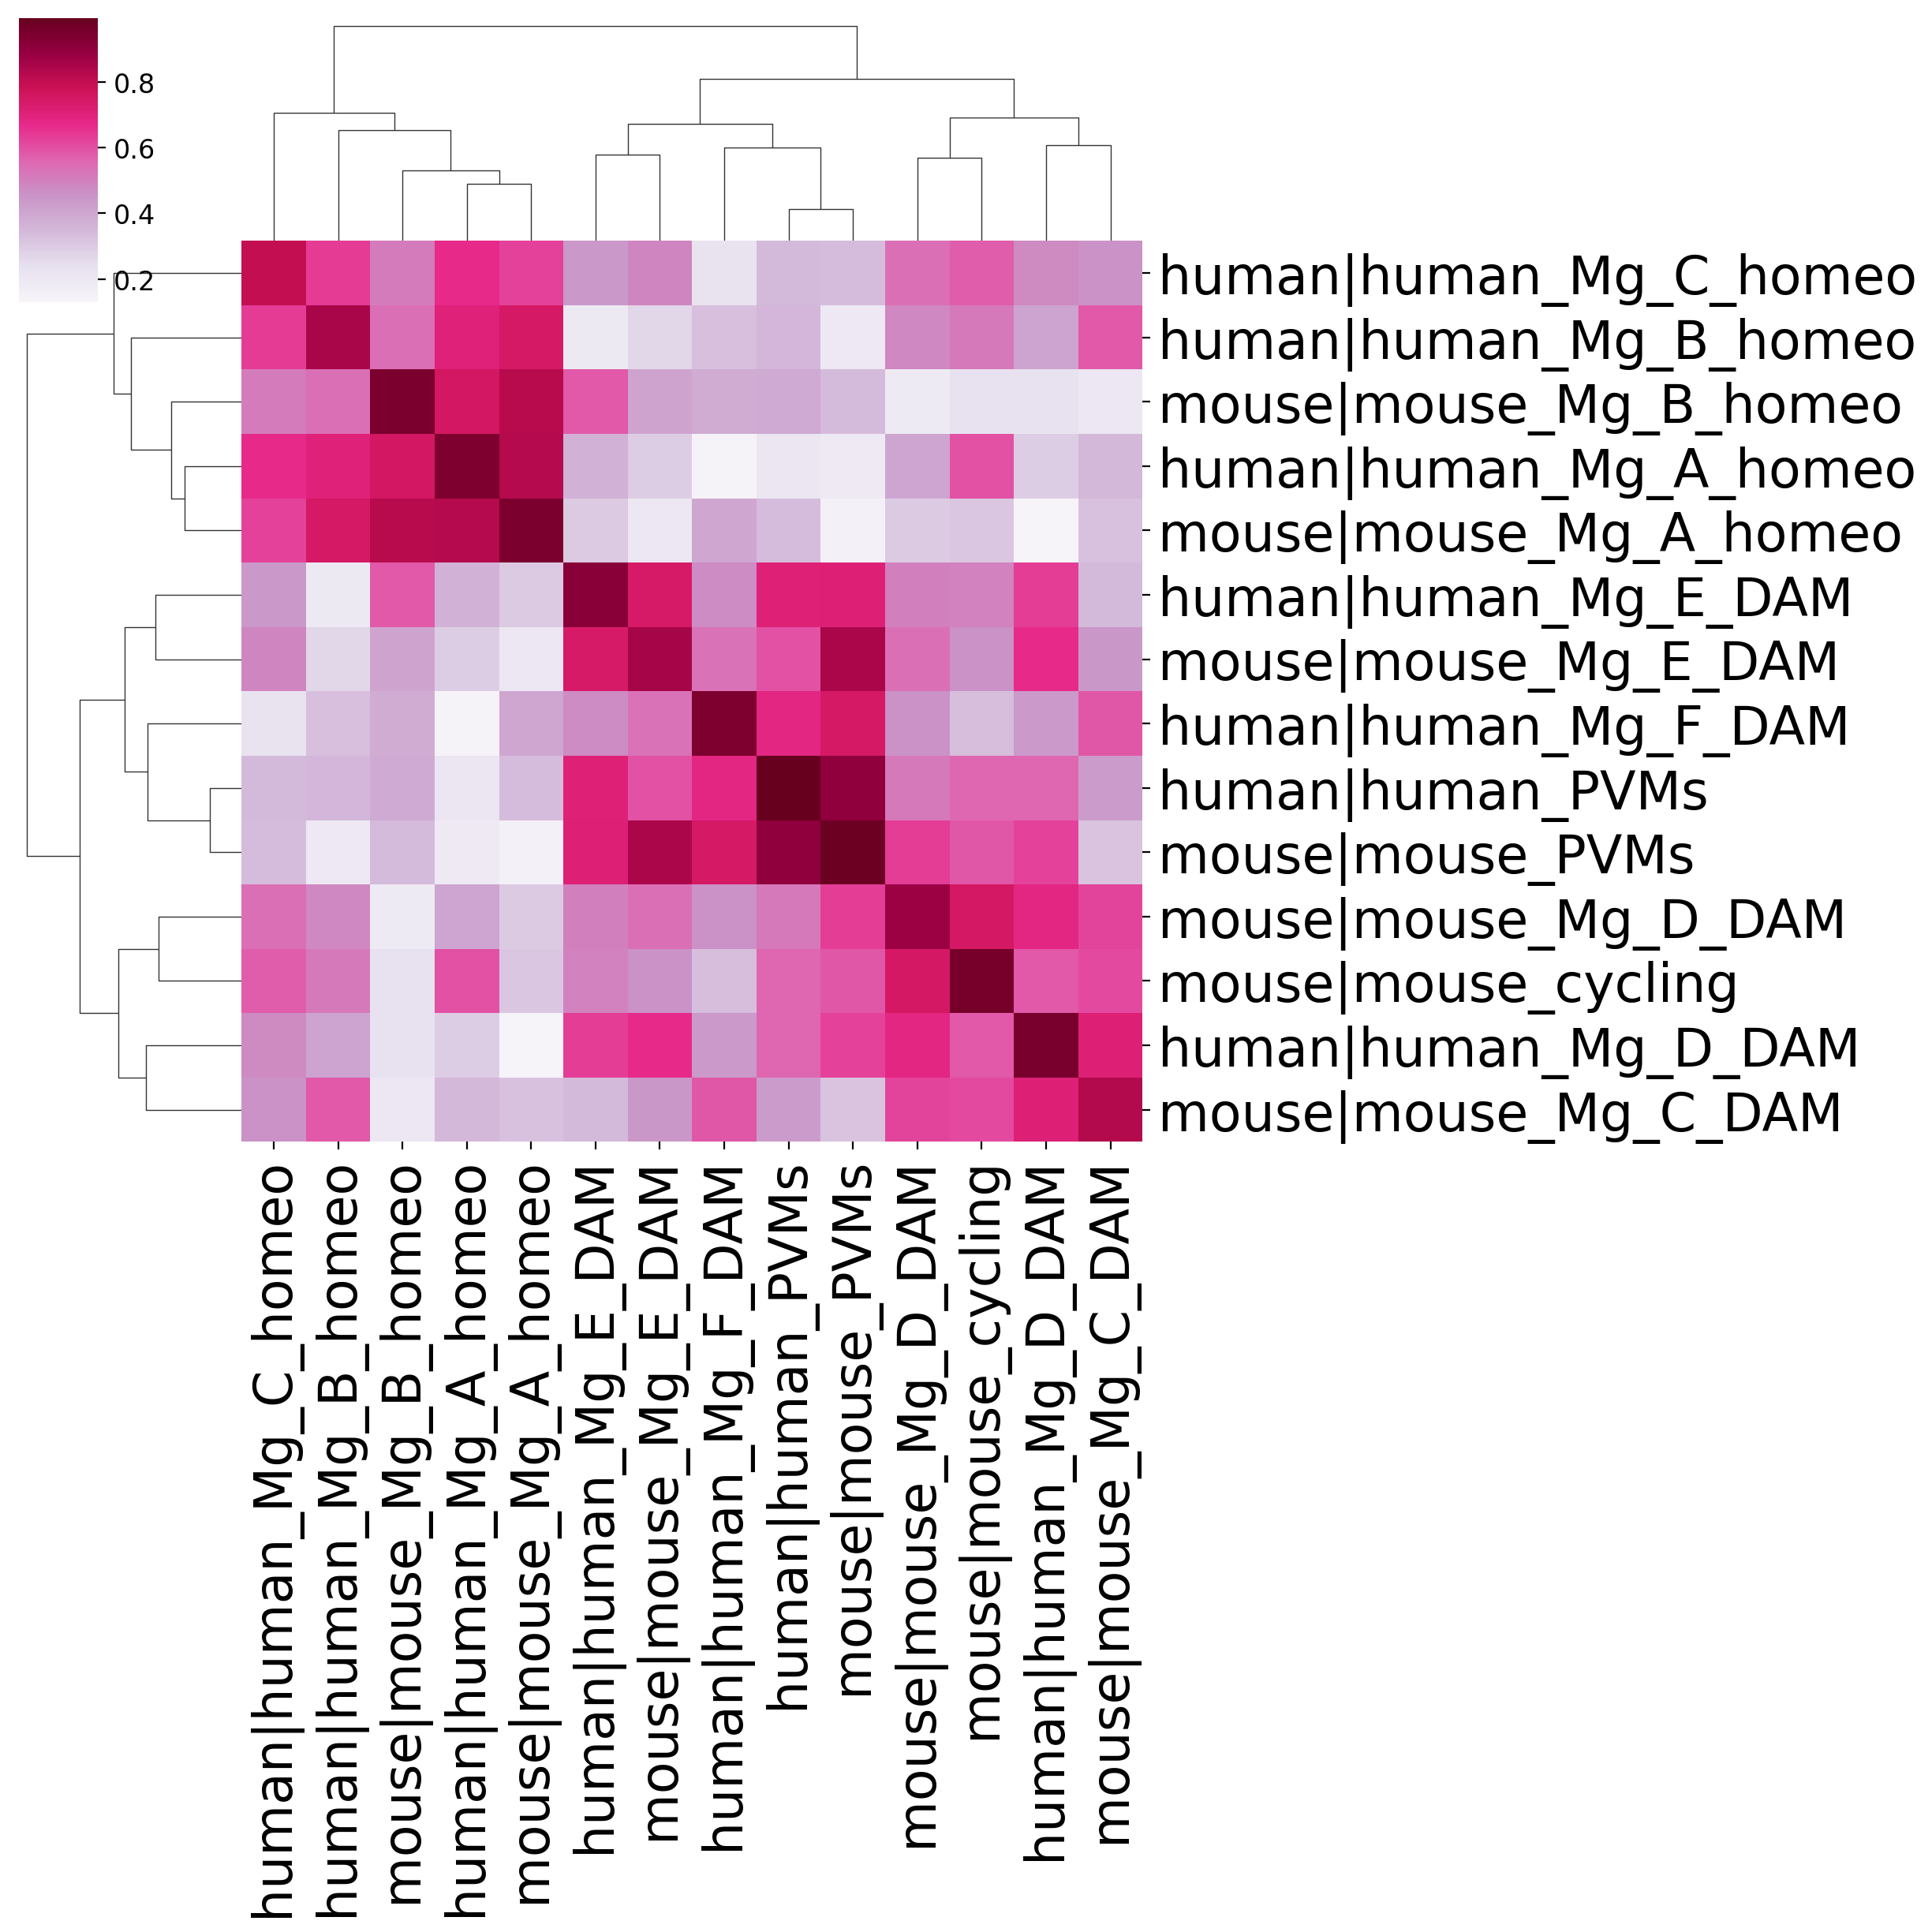

In [62]:
pymn_plot = pymn.plotMetaNeighborUS(adata_sub, 
                            figsize=(10, 10), 
                            cmap='PuRd', 
                            fontsize=24,
                            show=False)

# Save the plot as a high-resolution image (e.g., 300 dpi)
plt.savefig("MetaNeighborUS_AUROC_MG_plot_HVG3K_NEW.png", dpi=300, bbox_inches="tight")

# Show the plot (optional)
plt.show()

In [65]:
pymn.MetaNeighborUS(adata_sub,
                    study_col='study_id',
                    ct_col='cell.type',
                    fast_version=True,
                    symmetric_output=False,
                    one_vs_best=True)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


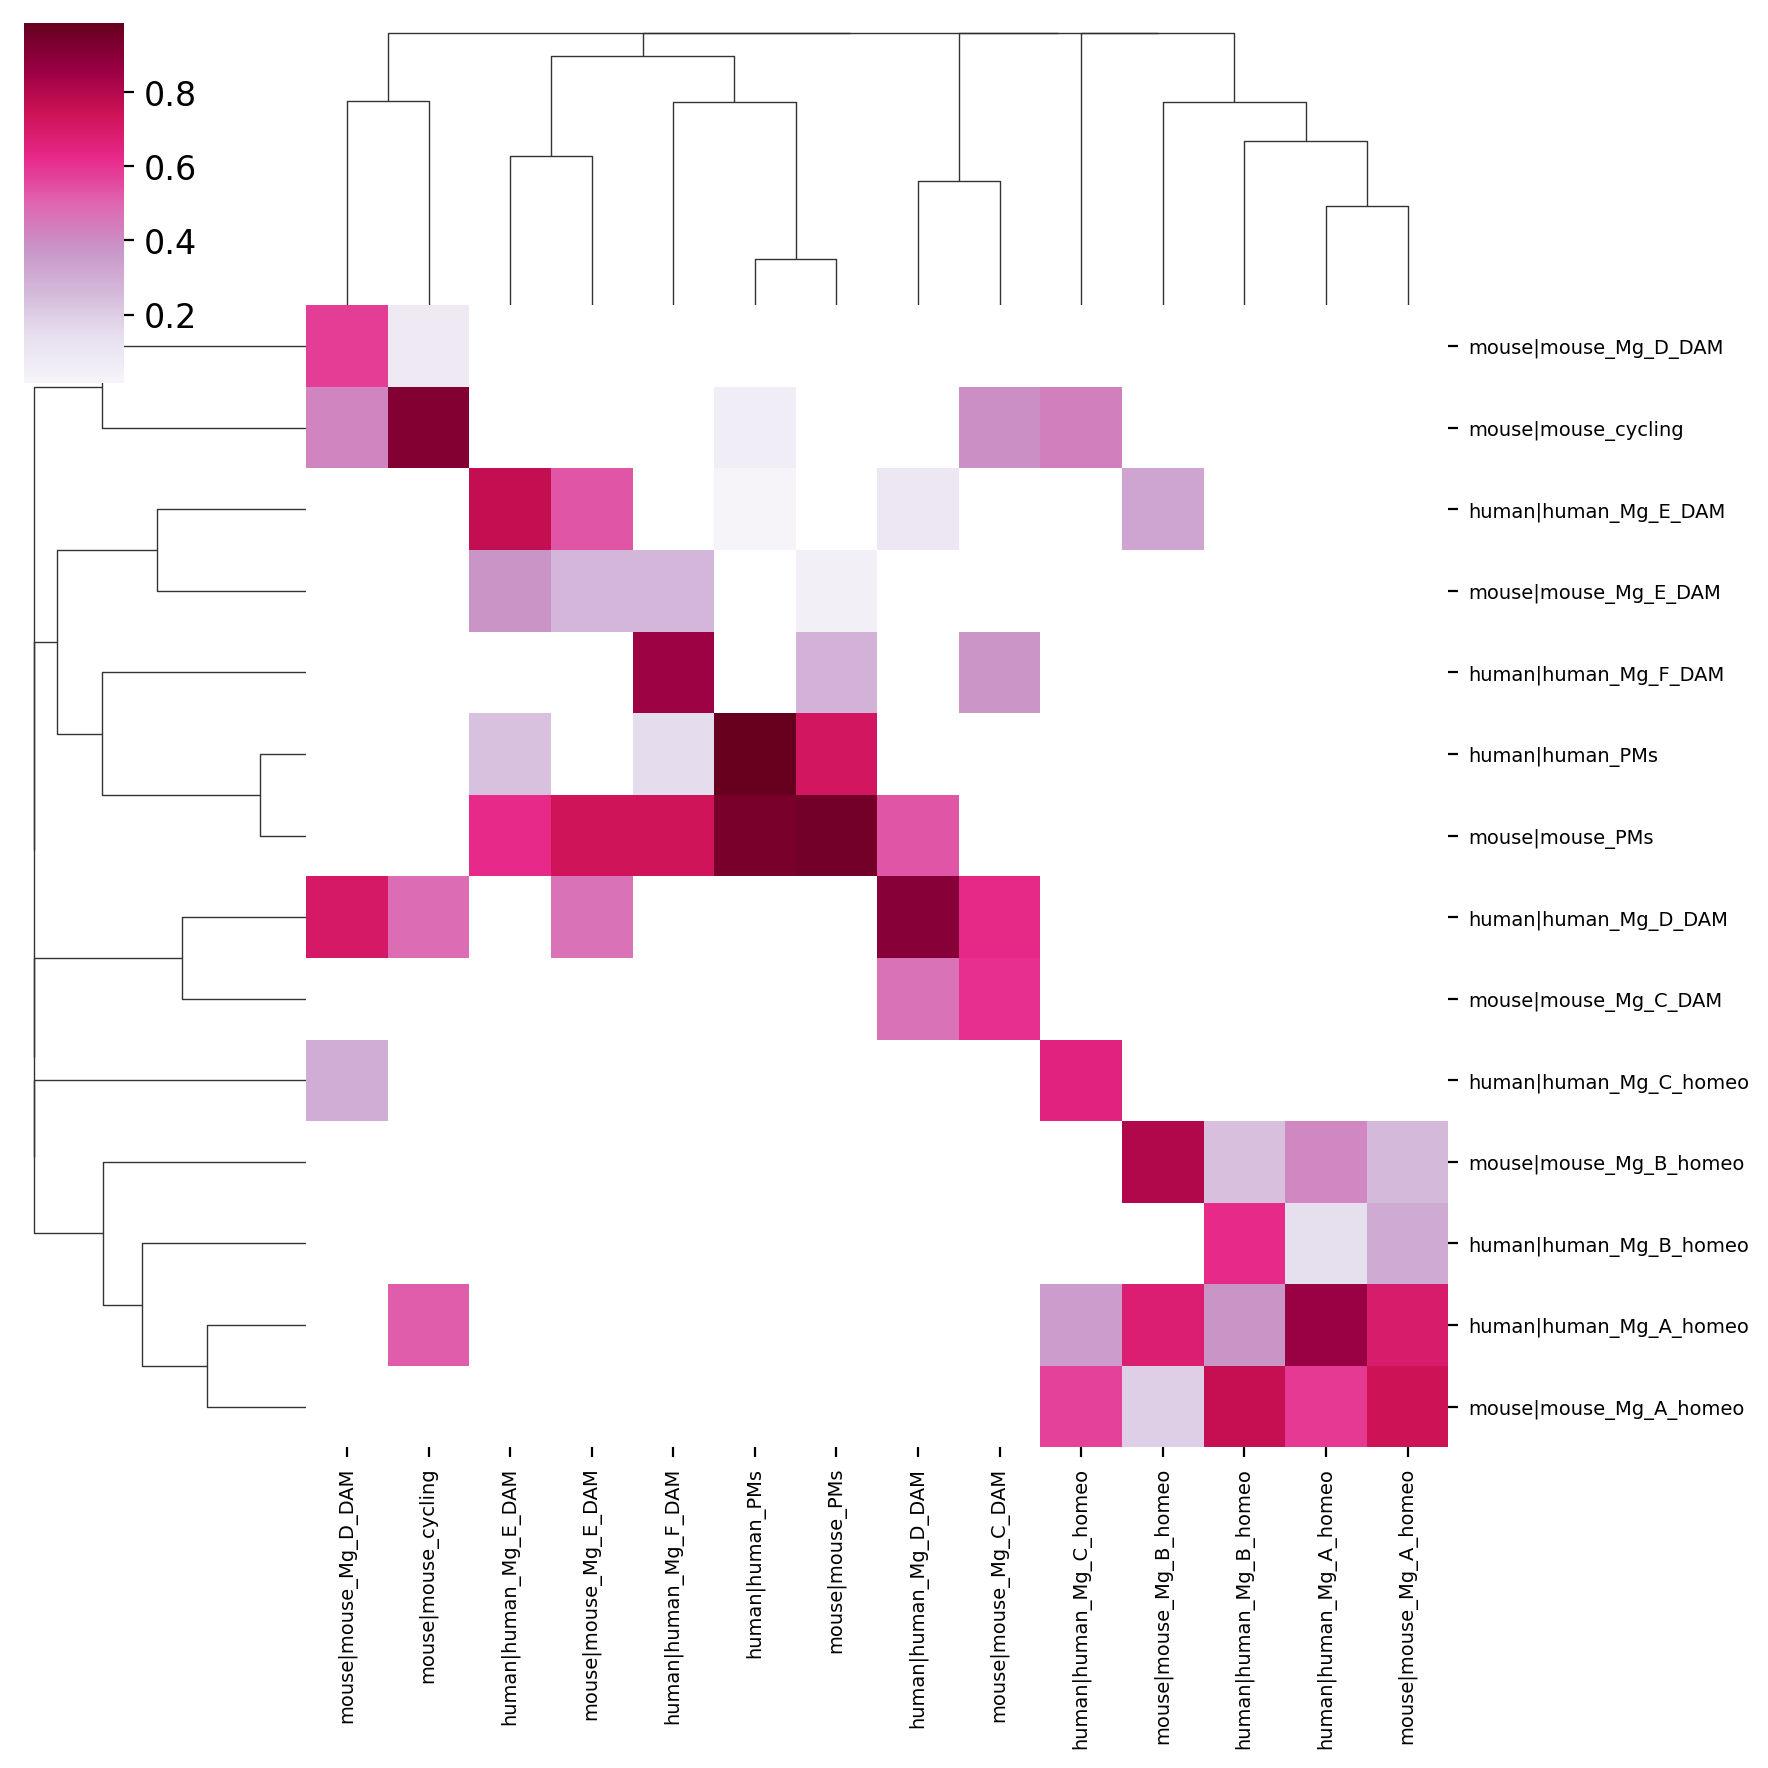

In [66]:
pymn.plotMetaNeighborUS(adata_sub,
                        cmap='PuRd',
                        figsize=(10, 10),
                        mn_key='MetaNeighborUS_1v1',
                        xticklabels=True,
                        yticklabels=True,
                        fontsize=7)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/edgeR/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


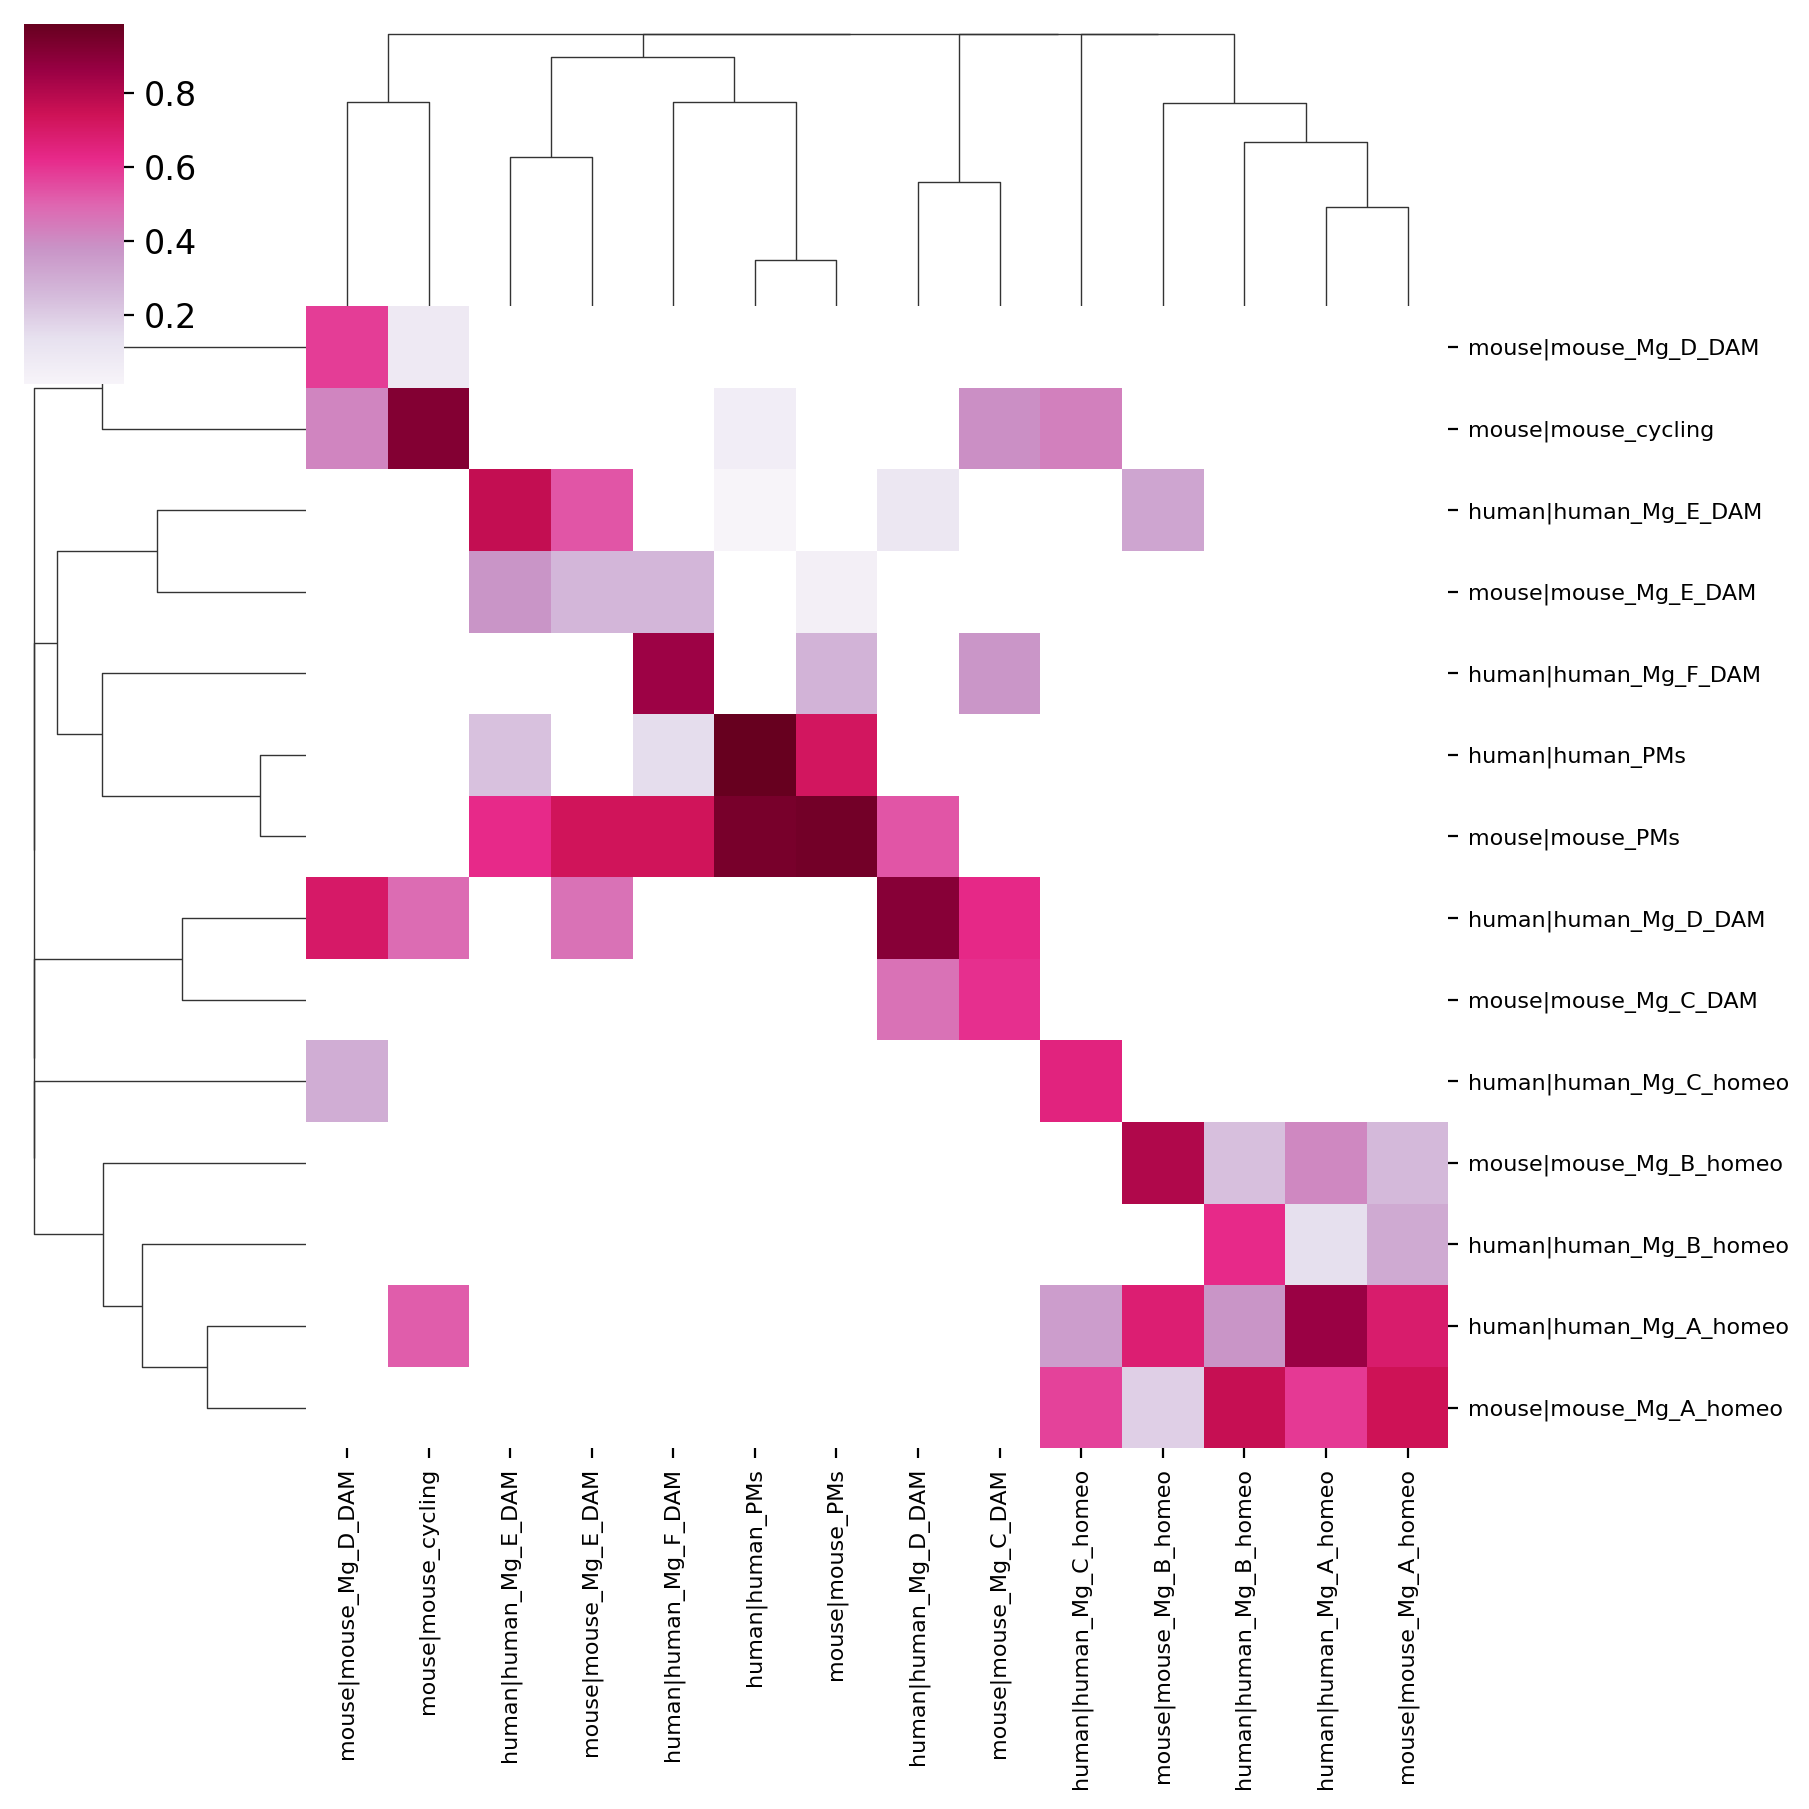

In [67]:
# Generate the MetaNeighborUS plot and save it to a variable
pymn_plot = pymn.plotMetaNeighborUS(
    adata_sub,
    cmap='PuRd',
    figsize=(10, 10),
    mn_key='MetaNeighborUS_1v1',
    xticklabels=True,
    yticklabels=True,
    fontsize=8,
    show=False  # Prevent immediate display
)

# Save the plot as a high-resolution image (e.g., 300 dpi)
plt.savefig("MetaNeighborUS_MG_plot_onevsbest_3khvg_NEW.png", dpi=300, bbox_inches="tight")

# Show the plot (optional)
plt.show()

In [68]:
adata_sub.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_h2m_balanced_MG_updated3kHVG_working.h5ad')

## Density plot

In [69]:
# Combine 'treatment' and 'condition' into one new column
adata_sub.obs["lesion_status"] = (
    adata_sub.obs["treatment"].astype(str) + "_" + adata_sub.obs["lesion_type"].astype(str)
)

In [70]:
# Combine 'treatment' and 'condition' into one new column
adata_sub.obs["treatment_condition"] = (
    adata_sub.obs["treatment"].astype(str) + "_" + adata_sub.obs["lesion_status"].astype(str)
)

# Check result
print(adata_sub.obs["treatment_condition"].unique())

['LPC_LPC_Demyelination' 'Saline_Saline_Control'
 'Cuprizone_Cuprizone_Demyelination' 'Normal_Normal_Control'
 'LPC_LPC_Remyelination (late)' 'No lesion_No lesion_Control'
 'LPC_LPC_Remyelination (early)' 'Cuprizone_Cuprizone_Remyelination'
 'MS_patient_MS_patient_WM' 'MS_patient_MS_patient_CIL'
 'MS_patient_MS_patient_RL' 'MS_patient_MS_patient_NAWM'
 'MS_patient_MS_patient_AL' 'MS_patient_MS_patient_CAL']

In [71]:
#cell_type = {str(i): '' for i in range(18)}
cell_type = {'LPC_LPC_Demyelination': 'LPC_demyel',
            'Saline_Saline_Control': 'LPC_baseline',
            'Cuprizone_Cuprizone_Demyelination': 'CPZ_demyel',
            'Normal_Normal_Control': 'CPZ_baseline',
            'LPC_LPC_Remyelination (late)': 'LPC_remyel',
            'No lesion_No lesion_Control': 'LPC_baseline',
            'LPC_LPC_Remyelination (early)': 'LPC_mid',
            'Cuprizone_Cuprizone_Remyelination': 'CPZ_remyel',
            'MS_patient_MS_patient_WM': 'WM',
            'MS_patient_MS_patient_CIL': 'CIL',
            'MS_patient_MS_patient_RL': 'RL',
            'MS_patient_MS_patient_NAWM': 'NAWM',
            'MS_patient_MS_patient_AL': 'AL',
            'MS_patient_MS_patient_CAL': 'CAL',
}

adata_sub.obs['lesion_status_reduced'] = adata_sub.obs['treatment_condition'].map(cell_type).astype('category')

In [72]:
adata_sub.obs['lesion_status_reduced'].value_counts()

lesion_status_reduced
LPC_demyel      15422
CPZ_demyel      13932
AL              10101
CAL              9174
CPZ_remyel       9038
LPC_mid          6607
NAWM             5049
WM               4622
CIL              4438
CPZ_baseline     4405
RL               4234
LPC_remyel       2716
LPC_baseline      861
Name: count, dtype: int64

In [74]:
AL = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='AL'],n_obs=850,copy=True).obs_names
NAWM = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='NAWM'],n_obs=850,copy=True).obs_names
CAL = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='CAL'],n_obs=850,copy=True).obs_names
WM_hs = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='WM'],n_obs=850,copy=True).obs_names
RL = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='RL'],n_obs=850,copy=True).obs_names
CIL = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='CIL'],n_obs=850,copy=True).obs_names

LPC_baseline = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='LPC_baseline'],n_obs=850,copy=True).obs_names
LPC_demyel = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='LPC_demyel'],n_obs=850,copy=True).obs_names
LPC_remyel = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='LPC_remyel'],n_obs=850,copy=True).obs_names
#LPC_14dpl = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_merged']=='LPC_14dpl'],n_obs=2429,copy=True).obs_names
CPZ_baseline = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='CPZ_baseline'],n_obs=850,copy=True).obs_names
CPZ_demyel = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='CPZ_demyel'],n_obs=850,copy=True).obs_names
CPZ_remyel = sc.pp.subsample(adata_sub[adata_sub.obs['lesion_status_reduced']=='CPZ_remyel'],n_obs=850,copy=True).obs_names

In [75]:
adata_subsample = adata_sub[list(LPC_baseline) + list(LPC_demyel) + list(LPC_remyel) +
                                list(CPZ_baseline) + list(CPZ_demyel) + list(CPZ_remyel) +
                                list(WM_hs) + list(NAWM) + list(AL) + list(CAL) + list(CIL) + list(RL)].copy()
adata_subsample.shape

(10200, 14311)

In [76]:
sc.tl.embedding_density(adata_subsample, basis='umap', groupby='lesion_status_reduced')

computing density on 'umap'
--> added
    'umap_density_lesion_status_reduced', densities (adata.obs)
    'umap_density_lesion_status_reduced_params', parameter (adata.uns)


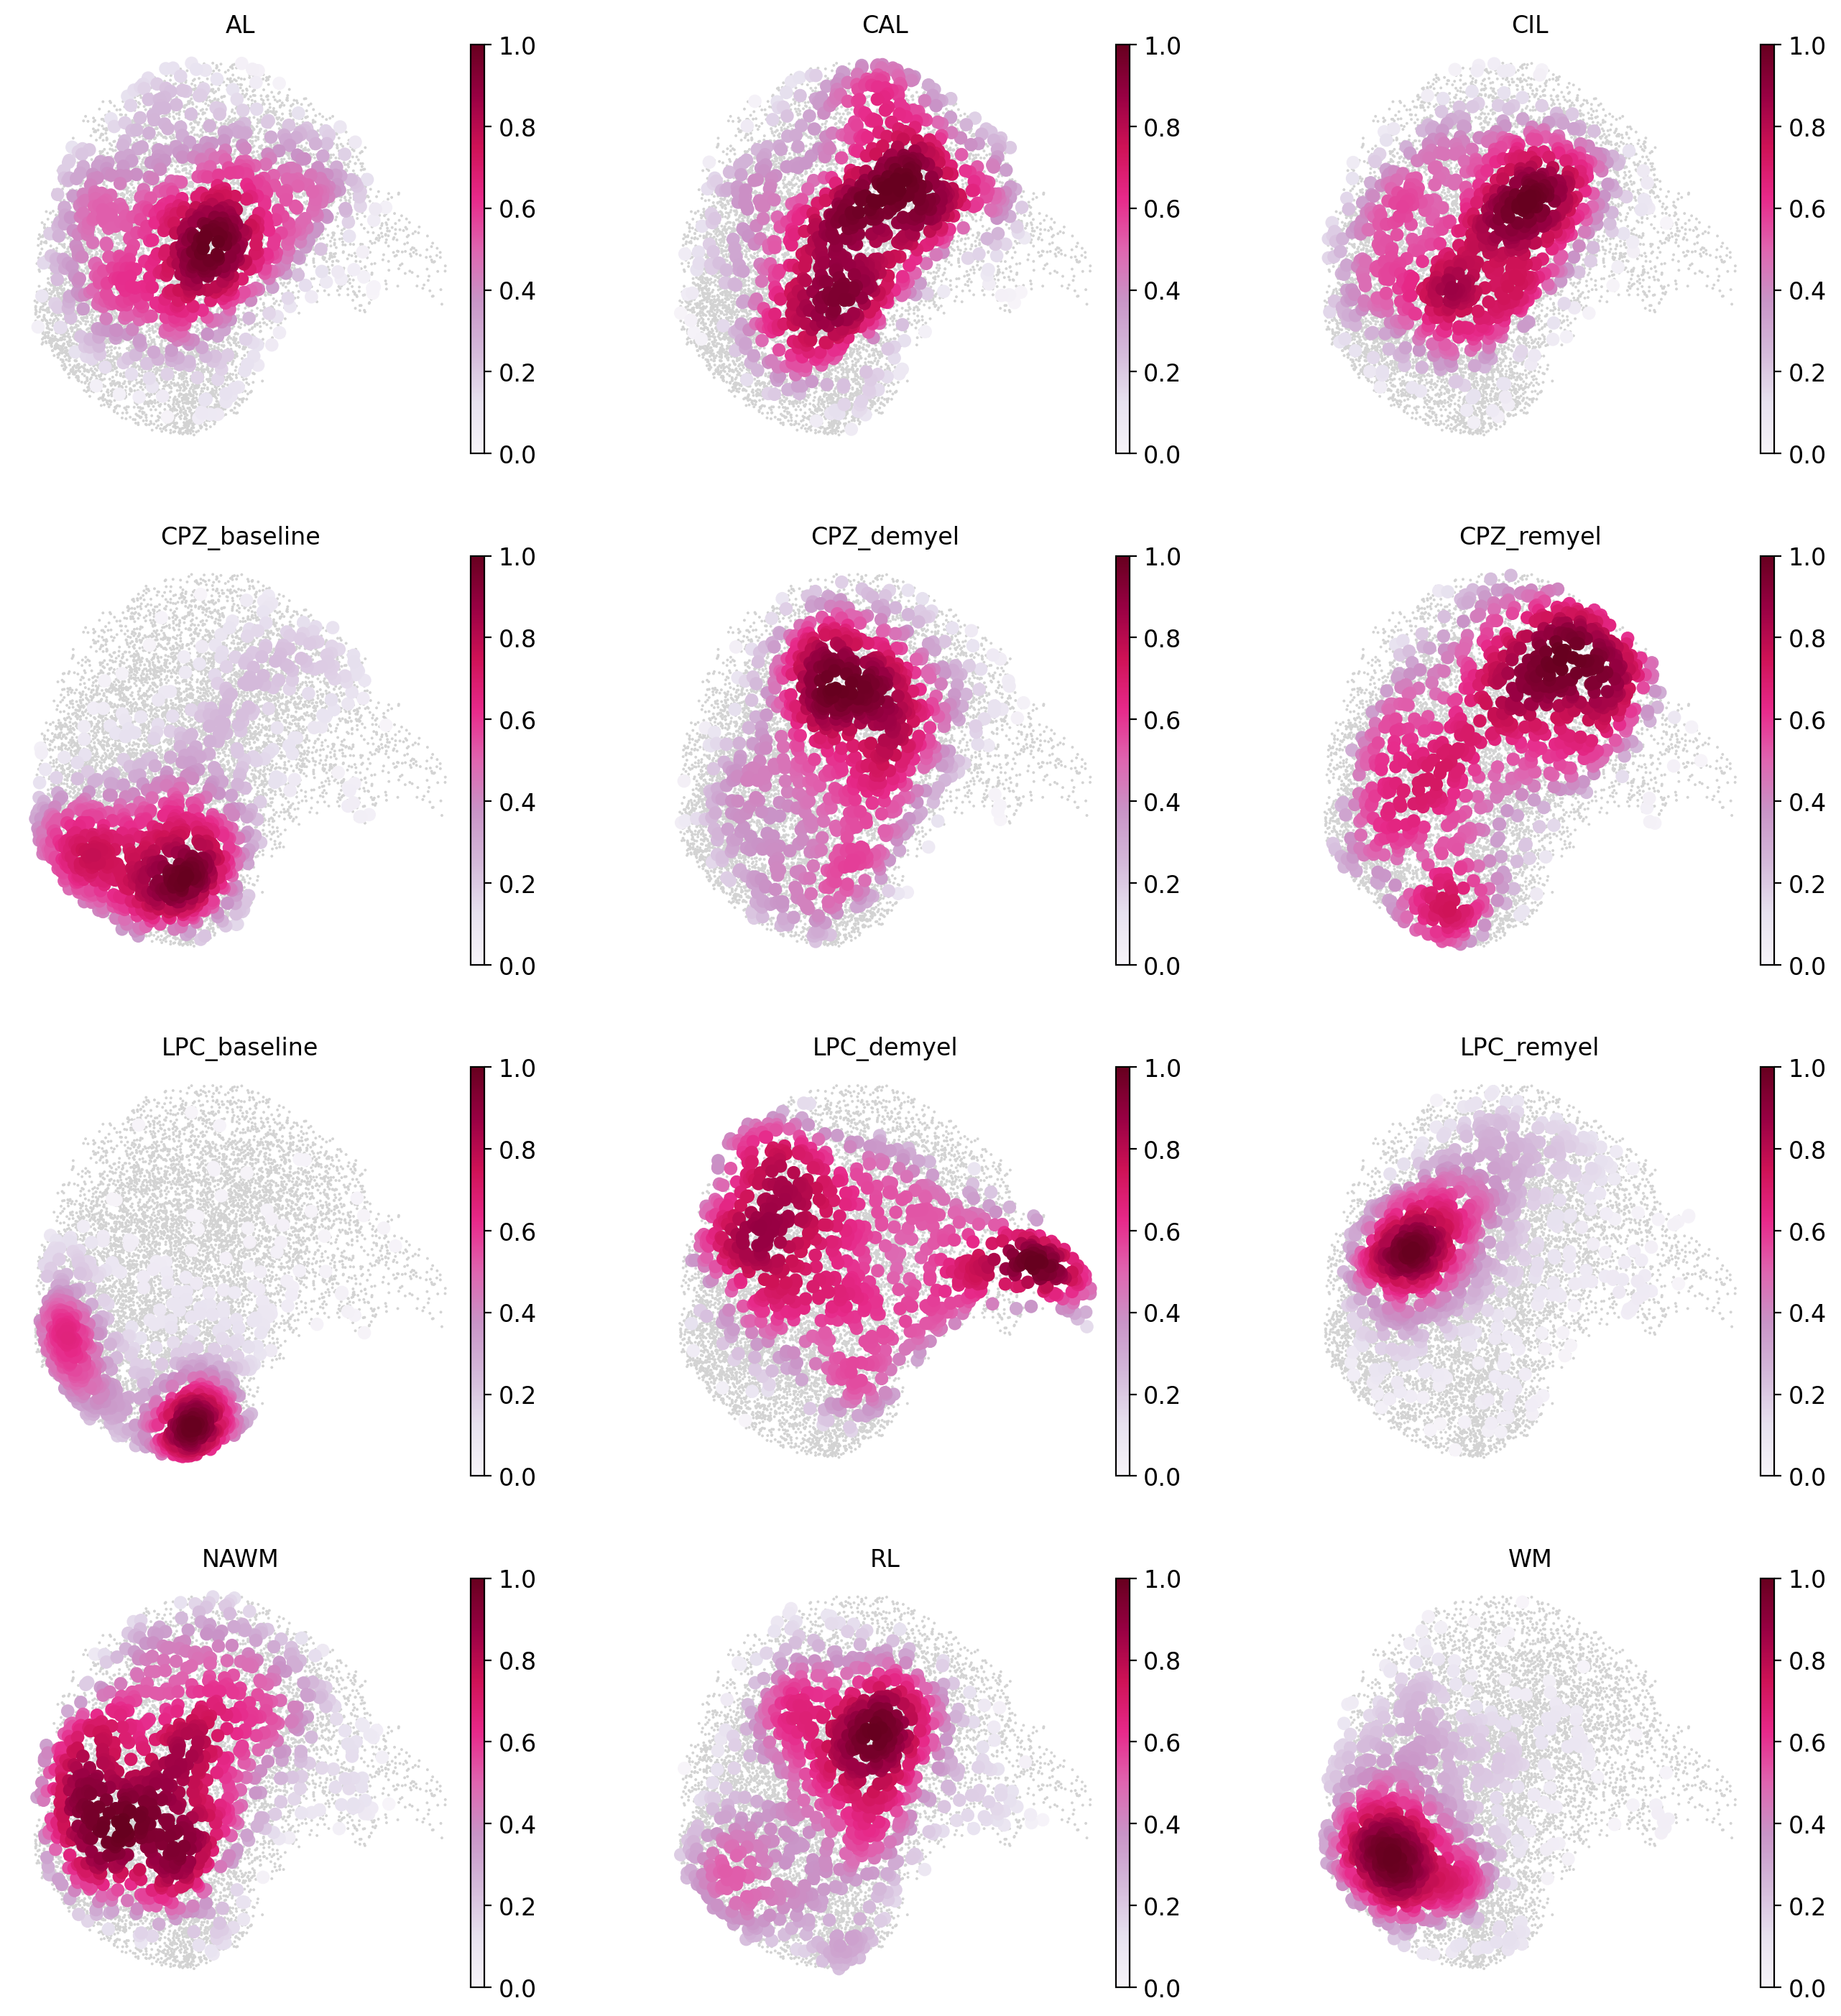

In [77]:
sc.pl.embedding_density(adata_subsample, basis='umap',  key='umap_density_lesion_status_reduced', color_map='PuRd', wspace=0.3, bg_dotsize = 8, frameon= False, 
                        ncols=3, save='_balanced_MG_distribution_downscaling_lesion_merged_N850.pdf')